# Durables vs Non Durables At Low And High Frequencies

The data are **real** personal consumption expenditures on durable and nondurable goods: nominal spending on each ([PCDG](https://fred.stlouisfed.org/series/PCDG) and [PCND](https://fred.stlouisfed.org/series/PCND) on FRED) divided by the price index for all of personal consumption, [PCECTPI](https://fred.stlouisfed.org/series/PCECTPI). Dividing both by the same index removes general inflation; unlike deflating each by its own price index, it leaves the ratio of the two series equal to the ratio of nominal spending on them. The data run through the latest quarter for which all three series are on FRED.

An earlier version of this notebook used nominal spending, undeflated. Inflation raises both nominal series together, so much of their apparent co-movement, particularly in the 1970s, came from common inflation rather than from the relationship between spending on durables and nondurables that the theory is about.

In [1]:
# Some initial setup
from matplotlib import pyplot as plt
import numpy as np
#plt.style.use('seaborn-darkgrid')
plt.style.use('seaborn-v0_8-darkgrid')
import pandas as pd
import datetime
import seaborn as sns

In [2]:
# Import Quarterly data from FRED, reading each series' CSV download directly
def fred(series):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"
    return pd.read_csv(url, index_col=0, parse_dates=True)


start = datetime.datetime(1947, 1, 1) #beginning of series
start1 = datetime.datetime(1956, 10, 1) #beginning of series

# Every quarter for which all three series are on FRED, through the latest
data = pd.concat([fred(s) for s in ['PCDG', 'PCND', 'PCECTPI']], axis=1).loc[start:].dropna()
end = data.index[-1] #end of series
print('Data from', data.index[0].date(), 'through', end.date())

# Real spending: nominal spending divided by the price index for all of personal consumption
real = data[['PCDG', 'PCND']].div(data['PCECTPI'], axis=0).set_axis(['Durables', 'Nondurables'], axis=1)

PCDG = real[['Durables']] #loads your durable goods quarterly series data
PCND = real[['Nondurables']] #Loads your non durable goods quarterly series data
PCDG1 = real.loc[start1:, ['Durables']] #loads your durable goods quarterly series data, helps in having time series of identical length
PCND1 = real.loc[start1:, ['Nondurables']] #Loads your non durable goods quarterly series data, , helps in having time series of identical length

Data from 1947-01-01 through 2026-04-01


In [3]:
# Constructing PCDG and PCND growth series () 
z1=PCDG.pct_change(periods=40)# 10*4
z2=PCND.pct_change(periods=40)#10*4
z3=PCDG1.pct_change(periods=1)# 
z4=PCND1.pct_change(periods=1)#
s1=z1*100 #(In percentage terms)
s2=z2*100 #(In percentage terms)
s3=z3*100 #(In percentage terms)
s4=z4*100 #(In percentage terms)

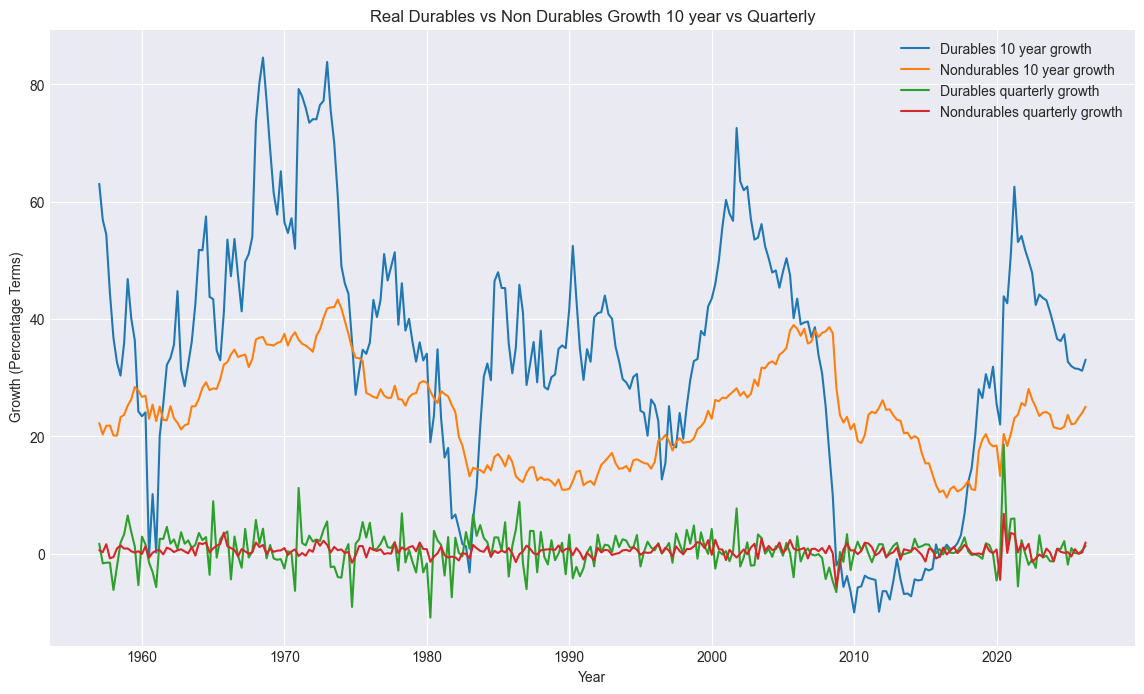

In [4]:
# Plotting the growth rates
plt.figure(figsize=((14,8))) # set the plot size
plt.title('Real Durables vs Non Durables Growth 10 year vs Quarterly')
plt.xlabel('Year')
plt.ylabel(' Growth (Percentage Terms)')
plt.plot(s1,label="Durables 10 year growth")
plt.plot(s2,label="Nondurables 10 year growth")
plt.plot(s3,label="Durables quarterly growth")
plt.plot(s4,label="Nondurables quarterly growth")
plt.legend()
plt.show()

In [5]:
# Drops the missing NAN observations

a1=s1.dropna()#Drops the missing values from s1 series
a2=s2.dropna()#Drops the missing values from s2 series
a3=s3.dropna()#Drops the missing values from s3 series
a4=s4.dropna()#Drops the missing values from s4 series

In [6]:
# concatate (merge) the two series
c1=pd.concat([a1, a2], axis=1)
c2=pd.concat([a3, a4], axis=1)

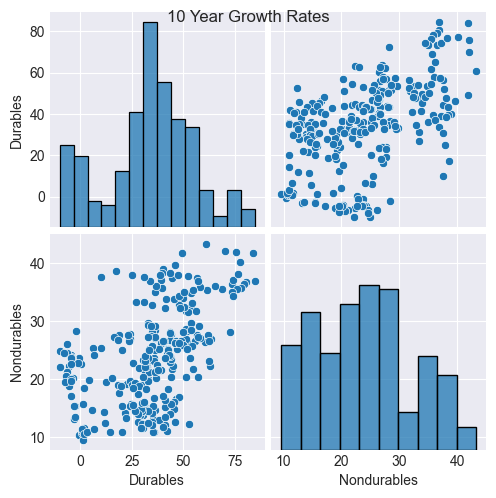

In [7]:
#Pairwise Plotting for the 10 year growth series

sns.pairplot(c1)
plt.suptitle('10 Year Growth Rates')
plt.show()

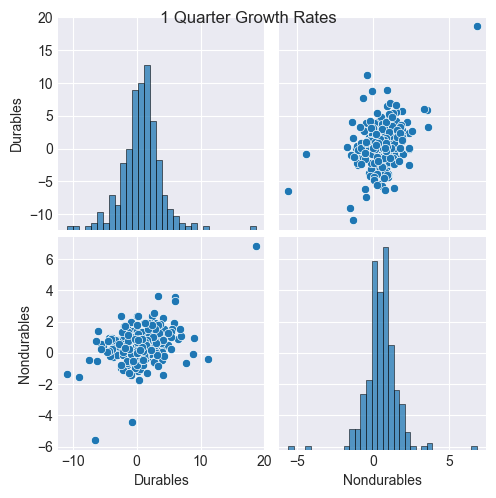

In [8]:
#Pairwise Plotting for the quarterly growth series

sns.pairplot(c2)
plt.suptitle('1 Quarter Growth Rates')
plt.show()

For each frequency [quarterly|10-year] each moment of time would correspond to a single point (x=nondurables growth, y=durables growth).  At both frequencies real spending on durables is far more variable than real spending on nondurables, and the more so at the 1 quarter frequency.